# 💎 Projet ML Complet — Diamonds Dataset
**Pipeline complet** : Chargement → EDA → Nettoyage → Feature Engineering → Encodage → Normalisation → Sélection → 8 Modèles → GridSearchCV → Cross-Validation → Feature Importances

| Étape | Détail |
|---|---|
| Dataset | Diamonds (seaborn) — 53 940 diamants, 9 features, cible : `price` |
| Catégorielles | `cut` (5 niv.), `color` (7 niv.), `clarity` (8 niv.) — toutes **ordinales** |
| Nouvelles features | `volume = x×y×z`, `ratio_depth_table = depth/table` |
| Encodage | `OrdinalEncoder` via `ColumnTransformer` |
| Normalisation | `MinMaxScaler` via `ColumnTransformer` |
| Sélection | `SelectKBest(f_regression, k=10)` |
| Modèles régression | Régression Linéaire, Arbre, SVR, Random Forest |
| Modèles classif. | Régression Logistique, Arbre Décision, SVC, Random Forest |
| Optimisation | `GridSearchCV` (5-Fold CV) |
| Évaluation | `cross_val_score` — KFold & StratifiedKFold |


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression, f_classif
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, f1_score, confusion_matrix,
                              classification_report)

print('Imports OK')


Imports OK


## 1. Chargement du dataset

In [ ]:
df = sns.load_dataset('diamonds')
print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head()


Shape : (53940, 10)
Colonnes : ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
print(df.dtypes)
print('\nValeurs manquantes :')
print(df.isnull().sum())
df.describe()


carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

Valeurs manquantes :
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


## 2. Choix des métriques
> **Régression** (cible : `price` en $)
> - **R²** : proportion de variance expliquée — métrique principale
> - **RMSE** : erreur en $, pénalise les grandes erreurs
> - **MAE** : erreur absolue moyenne, robuste aux outliers
>
> **Classification** (cible : `price_class` — diamant haut de gamme si price ≥ Q3)
> - **Accuracy** : % bien classés
> - **F1-Score** : équilibre précision/rappel (utile car classes déséquilibrées 75/25)
>
> *Justification : R² permet de comparer rapidement les modèles. RMSE est plus interprétable car exprimé en $.*


## 3. Exploration (EDA)

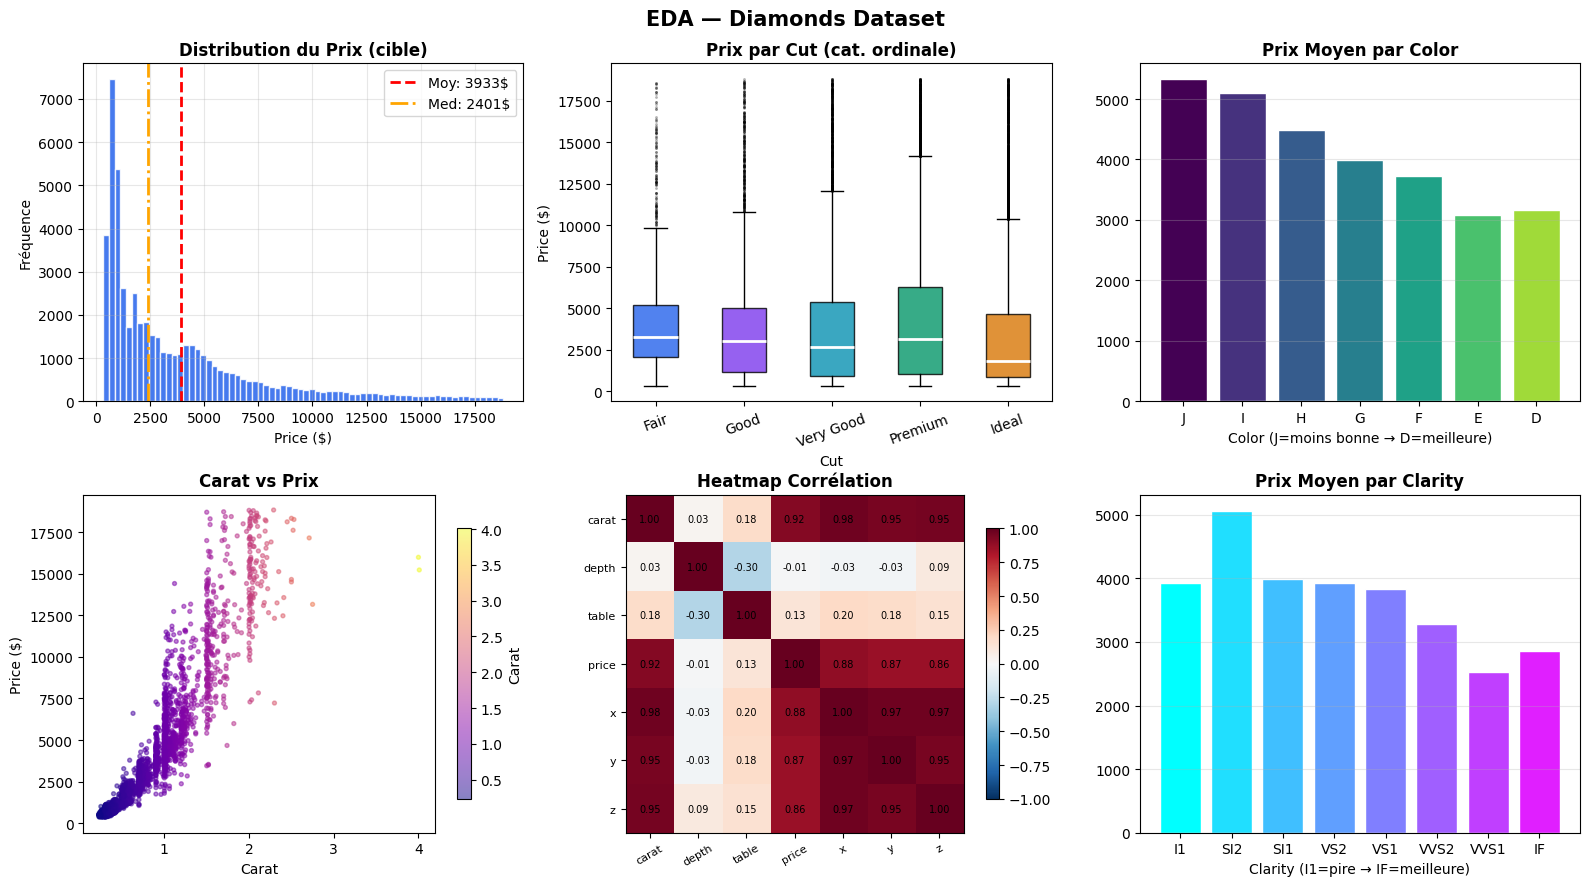

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('EDA — Diamonds Dataset', fontsize=15, fontweight='bold')

# Distribution prix
axes[0,0].hist(df['price'], bins=70, color='#2563EB', alpha=0.85, edgecolor='white')
axes[0,0].axvline(df['price'].mean(), color='red', lw=2, ls='--', label=f"Moy: {df['price'].mean():.0f}$")
axes[0,0].axvline(df['price'].median(), color='orange', lw=2, ls='-.', label=f"Med: {df['price'].median():.0f}$")
axes[0,0].set_title('Distribution du Prix (cible)', fontweight='bold')
axes[0,0].set_xlabel('Price ($)'); axes[0,0].set_ylabel('Fréquence')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# Prix par cut (ordre manuel car matplotlib ne supporte pas 'order')
cut_order_plot = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
data_cut = [df[df['cut'] == c]['price'].values for c in cut_order_plot]
bp = axes[0,1].boxplot(data_cut, labels=cut_order_plot, patch_artist=True,
                        medianprops=dict(color='white', lw=2),
                        flierprops=dict(marker='.', markersize=2, alpha=0.3))
for patch, col in zip(bp['boxes'], ['#2563EB','#7C3AED','#0891B2','#059669','#D97706']):
    patch.set_facecolor(col); patch.set_alpha(0.8)
axes[0,1].set_title('Prix par Cut (cat. ordinale)', fontweight='bold')
axes[0,1].set_xlabel('Cut'); axes[0,1].set_ylabel('Price ($)')
axes[0,1].tick_params(axis='x', rotation=20)

# Prix par color
color_order = ['J','I','H','G','F','E','D']
means_col = [df[df['color']==c]['price'].mean() for c in color_order]
axes[0,2].bar(color_order, means_col, color=plt.cm.viridis([i/7 for i in range(7)]), edgecolor='white')
axes[0,2].set_title('Prix Moyen par Color', fontweight='bold')
axes[0,2].set_xlabel('Color (J=moins bonne → D=meilleure)'); axes[0,2].grid(True, alpha=0.3, axis='y')

# Scatter carat vs prix
sample = df.sample(3000, random_state=42)
sc = axes[1,0].scatter(sample['carat'], sample['price'], c=sample['carat'],
                        cmap='plasma', alpha=0.5, s=8)
plt.colorbar(sc, ax=axes[1,0], label='Carat', shrink=0.8)
axes[1,0].set_title('Carat vs Prix', fontweight='bold')
axes[1,0].set_xlabel('Carat'); axes[1,0].set_ylabel('Price ($)')

# Heatmap corrélation
corr = df[['carat','depth','table','price','x','y','z']].corr()
im = axes[1,1].imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1,1].set_xticks(range(7)); axes[1,1].set_yticks(range(7))
axes[1,1].set_xticklabels(['carat','depth','table','price','x','y','z'], rotation=30, fontsize=8)
axes[1,1].set_yticklabels(['carat','depth','table','price','x','y','z'], fontsize=8)
for i in range(7):
    for j in range(7):
        axes[1,1].text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=axes[1,1], shrink=0.8)
axes[1,1].set_title('Heatmap Corrélation', fontweight='bold')

# Prix par clarity
clarity_order = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']
means_cl = [df[df['clarity']==c]['price'].mean() for c in clarity_order]
axes[1,2].bar(clarity_order, means_cl, color=plt.cm.cool([i/8 for i in range(8)]), edgecolor='white')
axes[1,2].set_title('Prix Moyen par Clarity', fontweight='bold')
axes[1,2].set_xlabel('Clarity (I1=pire → IF=meilleure)'); axes[1,2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('diamonds_fig1_eda.png', dpi=130, bbox_inches='tight')
plt.show()


## 4. Nettoyage des données

In [ ]:
print(f'Lignes avant nettoyage : {len(df):,}')

# 1) Supprimer les lignes avec x/y/z = 0 (mesures impossibles)
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]

# 2) Supprimer les outliers physiques aberrants
df = df[df['y'] < 20]   # y=58.9 mm est impossible pour un diamant
df = df[df['z'] < 10]   # z=31.8 mm idem

# 3) Supprimer les outliers de prix (méthode IQR × 3)
Q1, Q3 = df['price'].quantile([0.25, 0.75])
IQR    = Q3 - Q1
borne_inf = Q1 - 3 * IQR
borne_sup = Q3 + 3 * IQR
df = df[(df['price'] >= borne_inf) & (df['price'] <= borne_sup)]

df = df.reset_index(drop=True)
print(f'Lignes après nettoyage  : {len(df):,}')
print(f'Valeurs manquantes      : {df.isnull().sum().sum()}')
print(f'IQR×3 bornes prix       : [{borne_inf:.0f}$, {borne_sup:.0f}$]')


Lignes avant nettoyage : 53,940
Lignes après nettoyage  : 53,796
Valeurs manquantes      : 0
IQR×3 bornes prix       : [-12173$, 18445$]


## 5. Feature Engineering

In [ ]:
# Nouvelles features (domain knowledge)
df['volume']            = df['x'] * df['y'] * df['z']          # volume du diamant
df['ratio_depth_table'] = df['depth'] / df['table']             # forme de la table

print('Features créées :')
print(f"  volume           : mean={df['volume'].mean():.1f}  std={df['volume'].std():.1f}")
print(f"  ratio_depth_table: mean={df['ratio_depth_table'].mean():.2f}  std={df['ratio_depth_table'].std():.2f}")

# Définition des features et cibles
NUMERIC_COLS     = ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume', 'ratio_depth_table']
CATEGORICAL_COLS = ['cut', 'color', 'clarity']

# Cible régression
y_reg = df['price']

# Cible classification : price >= Q3 → diamant haut de gamme
SEUIL = df['price'].quantile(0.75)
y_cls = (df['price'] >= SEUIL).astype(int)
print(f'\nCible classif. : price >= Q3={SEUIL:.0f}$ → {y_cls.mean()*100:.1f}% classe 1 (haut de gamme)')

X = df[NUMERIC_COLS + CATEGORICAL_COLS].copy()
print(f'Shape X : {X.shape}  ({len(NUMERIC_COLS)} num. + {len(CATEGORICAL_COLS)} cat.)')


Features créées :
  volume           : mean=129.3  std=75.8
  ratio_depth_table: mean=1.08  std=0.05

Cible classif. : price >= Q3=5293$ → 25.0% classe 1 (haut de gamme)
Shape X : (53796, 11)  (8 num. + 3 cat.)


## 6. Préprocessing — ColumnTransformer + SelectKBest

In [ ]:
# Ordre des catégories (variables ORDINALES)
cut_order     = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']         # qualité croissante
color_order   = ['J', 'I', 'H', 'G', 'F', 'E', 'D']                      # J=pire, D=meilleure
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'] # I1=pire, IF=meilleure

# ColumnTransformer : MinMaxScaler + OrdinalEncoder
preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), NUMERIC_COLS),
    ('cat', OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), CATEGORICAL_COLS),
])

feat_names = NUMERIC_COLS + [f'{c}_enc' for c in CATEGORICAL_COLS]
X_proc = pd.DataFrame(preprocessor.fit_transform(X), columns=feat_names)
print(f'Après ColumnTransformer : {X_proc.shape}')
X_proc.head()


Après ColumnTransformer : (53796, 11)


,carat,depth,table,x,y,z,volume,ratio_depth_table,cut_enc,color_enc,clarity_enc
0,0.006237,0.513889,0.230769,0.031384,0.043732,0.230118,0.008563,0.592636,4.0,5.0,1.0
1,0.002079,0.466667,0.346154,0.022825,0.023324,0.209814,0.003689,0.429678,3.0,5.0,2.0
2,0.006237,0.386111,0.423077,0.045649,0.056851,0.209814,0.008398,0.305624,1.0,5.0,4.0
3,0.018711,0.538889,0.288462,0.067047,0.080175,0.263959,0.019800,0.542610,3.0,1.0,3.0
4,0.022869,0.563889,0.288462,0.087019,0.097668,0.284264,0.026646,0.560953,1.0,0.0,1.0


In [ ]:
# Feature Selection : SelectKBest(f_regression, k=10)
selector = SelectKBest(f_regression, k=10)
X_sel    = selector.fit_transform(X_proc, y_reg)
FEATS    = X_proc.columns[selector.get_support()].tolist()
X_final  = pd.DataFrame(X_sel, columns=FEATS)

print(f'Features sélectionnées (k=10) :')
scores = selector.scores_[selector.get_support()]
for f, s in sorted(zip(FEATS, scores), key=lambda x: -x[1]):
    print(f'  {f:<25} score F = {s:.1f}')

# Split Train/Test 80/20
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_final, y_reg, test_size=0.2, random_state=42)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_final, y_cls, test_size=0.2, random_state=42, stratify=y_cls)
print(f'\nSplit 80/20 : Train={len(X_tr_r):,} | Test={len(X_te_r):,}')


Features sélectionnées (k=10) :
  volume                    score F = 311513.0
  carat                     score F = 302602.5
  y                         score F = 203300.8
  x                         score F = 199841.1
  z                         score F = 189484.9
  color_enc                 score F = 1635.3
  clarity_enc               score F = 1176.2
  table                     score F = 884.6
  ratio_depth_table         score F = 592.4
  cut_enc                   score F = 154.8

Split 80/20 : Train=43,036 | Test=10,760


## 7. Modèles de Régression + GridSearchCV

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
R  = {}  # stockage des résultats

def eval_reg(name, model, Xte, yte):
    yp = model.predict(Xte)
    cv = cross_val_score(model, X_final, y_reg, cv=kf, scoring='r2')
    R[name] = dict(model=model, cv=cv, yp=yp,
                   r2=r2_score(yte, yp),
                   rmse=np.sqrt(mean_squared_error(yte, yp)),
                   mae=mean_absolute_error(yte, yp))
    print(f'  {name:<30} R²={R[name]["r2"]:.4f}  RMSE={R[name]["rmse"]:.0f}$  CV={cv.mean():.4f}±{cv.std():.4f}')

# 1. Régression Linéaire (baseline)
m = LinearRegression().fit(X_tr_r, y_tr_r)
eval_reg('Régression Linéaire', m, X_te_r, y_te_r)

# 2. Arbre de Régression + GridSearch
gs = GridSearchCV(DecisionTreeRegressor(random_state=42),
                  {'max_depth': [6, 8, 12], 'min_samples_split': [20, 50]},
                  cv=kf, scoring='r2', n_jobs=-1)
gs.fit(X_tr_r, y_tr_r)
print(f'  Arbre best params: {gs.best_params_}')
eval_reg('Arbre de Régression', gs.best_estimator_, X_te_r, y_te_r)
R['Arbre de Régression']['fi'] = gs.best_estimator_.feature_importances_

# 3. SVR + GridSearch (subset pour rapidité)
idx = np.random.choice(len(X_tr_r), min(3000, len(X_tr_r)), replace=False)
gs  = GridSearchCV(SVR(), {'C': [1, 10, 100], 'epsilon': [0.05, 0.1]},
                   cv=3, scoring='r2', n_jobs=-1)
gs.fit(X_tr_r.iloc[idx], y_tr_r.iloc[idx])
print(f'  SVR best params: {gs.best_params_}')
m = SVR(**gs.best_params_).fit(X_tr_r, y_tr_r)
eval_reg('SVR', m, X_te_r, y_te_r)

# 4. Random Forest Régression + GridSearch
gs = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                  {'n_estimators': [100, 200], 'max_depth': [10, 15]},
                  cv=kf, scoring='r2', n_jobs=-1)
gs.fit(X_tr_r, y_tr_r)
print(f'  RF best params: {gs.best_params_}')
eval_reg('Random Forest Rég.', gs.best_estimator_, X_te_r, y_te_r)
R['Random Forest Rég.']['fi'] = gs.best_estimator_.feature_importances_


  Régression Linéaire            R²=0.9128  RMSE=1137$  CV=0.9099±0.0024
  Arbre best params: {'max_depth': 12, 'min_samples_split': 20}
  Arbre de Régression            R²=0.9765  RMSE=590$  CV=0.9763±0.0002
  SVR best params: {'C': 100, 'epsilon': 0.05}
  SVR                            R²=0.7857  RMSE=1782$  CV=0.7818±0.0035
  RF best params: {'max_depth': 15, 'n_estimators': 200}
  Random Forest Rég.             R²=0.9816  RMSE=522$  CV=0.9820±0.0005


## 8. Modèles de Classification + GridSearchCV

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
C   = {}  # stockage des résultats

def eval_cls(name, model, Xte, yte):
    yp = model.predict(Xte)
    cv = cross_val_score(model, X_final, y_cls, cv=skf, scoring='f1')
    C[name] = dict(model=model, cv=cv, yp=yp,
                   acc=accuracy_score(yte, yp),
                   f1=f1_score(yte, yp))
    print(f'  {name:<30} Acc={C[name]["acc"]:.4f}  F1={C[name]["f1"]:.4f}  CV={cv.mean():.4f}±{cv.std():.4f}')

# 5. Régression Logistique
gs = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                  {'C': [0.01, 0.1, 1, 10]}, cv=skf, scoring='f1', n_jobs=-1)
gs.fit(X_tr_c, y_tr_c)
print(f'  Logistic best params: {gs.best_params_}')
eval_cls('Régression Logistique', gs.best_estimator_, X_te_c, y_te_c)

# 6. Arbre de Décision
gs = GridSearchCV(DecisionTreeClassifier(random_state=42),
                  {'max_depth': [6, 8, 12], 'criterion': ['gini', 'entropy']},
                  cv=skf, scoring='f1', n_jobs=-1)
gs.fit(X_tr_c, y_tr_c)
print(f'  DT best params: {gs.best_params_}')
eval_cls('Arbre de Décision', gs.best_estimator_, X_te_c, y_te_c)
C['Arbre de Décision']['fi'] = gs.best_estimator_.feature_importances_

# 7. SVC (subset pour rapidité)
idx = np.random.choice(len(X_tr_c), min(3000, len(X_tr_c)), replace=False)
gs  = GridSearchCV(SVC(random_state=42),
                   {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']},
                   cv=3, scoring='f1', n_jobs=-1)
gs.fit(X_tr_c.iloc[idx], y_tr_c.iloc[idx])
print(f'  SVC best params: {gs.best_params_}')
m = SVC(**gs.best_params_, random_state=42).fit(X_tr_c, y_tr_c)
eval_cls('SVC', m, X_te_c, y_te_c)

# 8. Random Forest Classification
gs = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                  {'n_estimators': [100, 200], 'max_depth': [10, 15]},
                  cv=skf, scoring='f1', n_jobs=-1)
gs.fit(X_tr_c, y_tr_c)
print(f'  RF best params: {gs.best_params_}')
eval_cls('Random Forest Cls.', gs.best_estimator_, X_te_c, y_te_c)
C['Random Forest Cls.']['fi'] = gs.best_estimator_.feature_importances_


  Logistic best params: {'C': 10}
  Régression Logistique          Acc=0.9651  F1=0.9299  CV=0.9250±0.0036
  DT best params: {'criterion': 'gini', 'max_depth': 8}
  Arbre de Décision              Acc=0.9739  F1=0.9475  CV=0.9462±0.0023
  SVC best params: {'C': 10, 'kernel': 'rbf'}
  SVC                            Acc=0.9743  F1=0.9485  CV=0.9473±0.0013
  RF best params: {'max_depth': 15, 'n_estimators': 200}
  Random Forest Cls.             Acc=0.9777  F1=0.9552  CV=0.9531±0.0021


## 9. Évaluation & Cross-Validation — Résumé

In [ ]:
rn = list(R.keys()); cn = list(C.keys())

print('RÉGRESSION')
print(f'{"Modèle":<30} {"R²":>8} {"RMSE ($)":>10} {"MAE ($)":>9} {"CV R² moy":>12} {"std":>7}')
print('-'*80)
for n,r in R.items():
    print(f'{n:<30} {r["r2"]:>8.4f} {r["rmse"]:>10.1f} {r["mae"]:>9.1f} '
          f'{r["cv"].mean():>12.4f} {r["cv"].std():>7.4f}')

print('\nCLASSIFICATION')
print(f'{"Modèle":<30} {"Accuracy":>10} {"F1":>8} {"CV F1 moy":>12} {"std":>7}')
print('-'*68)
for n,r in C.items():
    print(f'{n:<30} {r["acc"]:>10.4f} {r["f1"]:>8.4f} '
          f'{r["cv"].mean():>12.4f} {r["cv"].std():>7.4f}')


RÉGRESSION
Modèle                               R²   RMSE ($)   MAE ($)    CV R² moy     std
--------------------------------------------------------------------------------
Régression Linéaire              0.9128     1137.0     762.5       0.9099  0.0024
Arbre de Régression              0.9765      589.8     306.1       0.9763  0.0002
SVR                              0.7857     1782.1     948.5       0.7818  0.0035
Random Forest Rég.               0.9816      522.3     259.3       0.9820  0.0005

CLASSIFICATION
Modèle                           Accuracy       F1    CV F1 moy     std
--------------------------------------------------------------------
Régression Logistique              0.9651   0.9299       0.9250  0.0036
Arbre de Décision                  0.9739   0.9475       0.9462  0.0023
SVC                                0.9743   0.9485       0.9473  0.0013
Random Forest Cls.                 0.9777   0.9552       0.9531  0.0021


## 10. Feature Importances

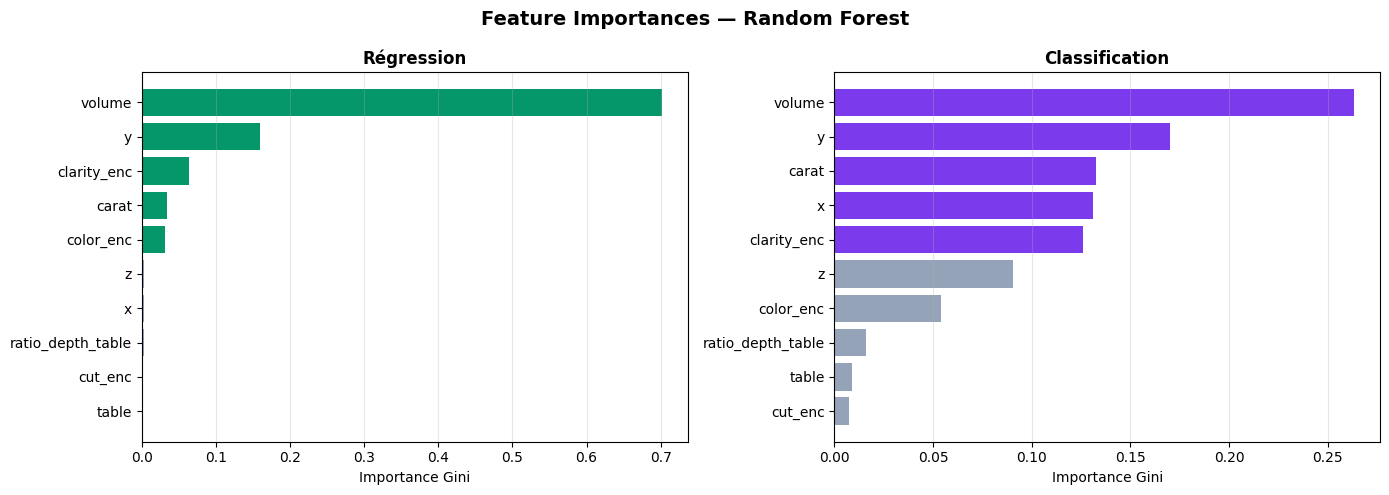

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Importances — Random Forest', fontsize=14, fontweight='bold')

# Régression
fi_r = R['Random Forest Rég.']['fi']
idx_s = np.argsort(fi_r)
axes[0].barh(np.array(FEATS)[idx_s], fi_r[idx_s],
             color=['#059669' if v >= np.percentile(fi_r, 50) else '#94A3B8' for v in fi_r[idx_s]])
axes[0].set_title('Régression', fontweight='bold')
axes[0].set_xlabel('Importance Gini')
axes[0].grid(True, alpha=0.3, axis='x')

# Classification
fi_c = C['Random Forest Cls.']['fi']
idx_s = np.argsort(fi_c)
axes[1].barh(np.array(FEATS)[idx_s], fi_c[idx_s],
             color=['#7C3AED' if v >= np.percentile(fi_c, 50) else '#94A3B8' for v in fi_c[idx_s]])
axes[1].set_title('Classification', fontweight='bold')
axes[1].set_xlabel('Importance Gini')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('diamonds_feature_importances.png', dpi=130, bbox_inches='tight')
plt.show()


## 11. Visualisation — Modèles de Régression

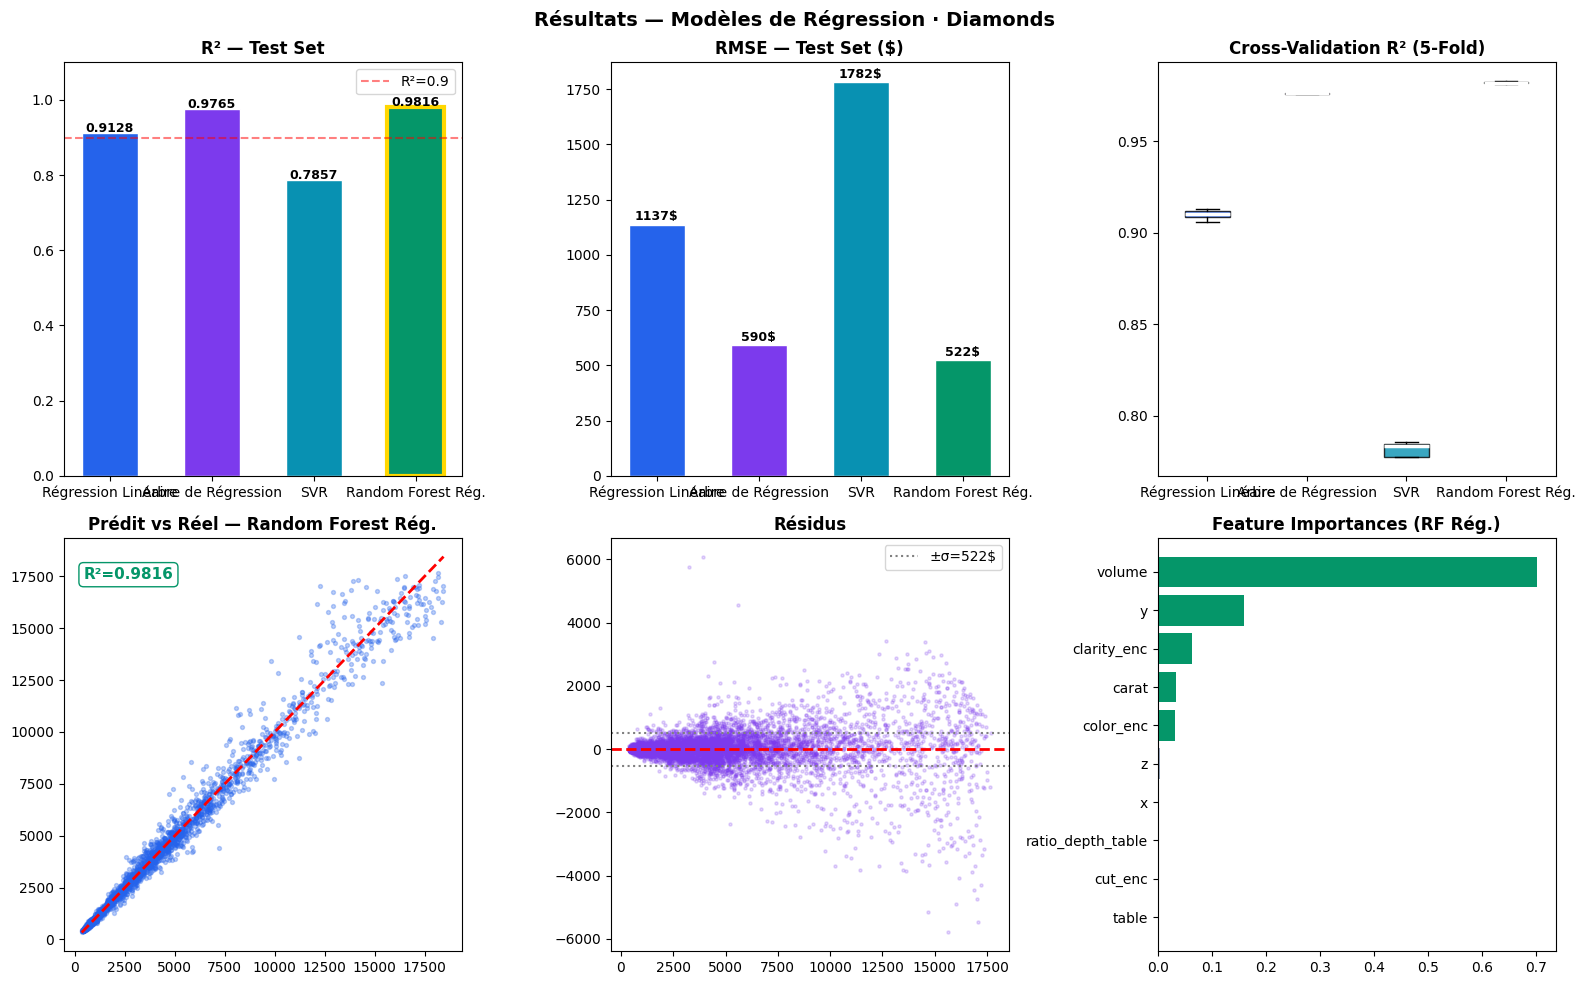

In [ ]:
COLORS = ['#2563EB','#7C3AED','#0891B2','#059669']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Résultats — Modèles de Régression · Diamonds', fontsize=14, fontweight='bold')

r2v  = [R[n]['r2']   for n in rn]
rmse_v = [R[n]['rmse'] for n in rn]
idx_b = np.argmax(r2v)

# R²
bars = axes[0,0].bar(rn, r2v, color=COLORS, edgecolor='white', width=0.55)
for b,v in zip(bars,r2v): axes[0,0].text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
bars[idx_b].set_edgecolor('gold'); bars[idx_b].set_linewidth(3)
axes[0,0].axhline(0.9, color='red', lw=1.5, ls='--', alpha=0.5, label='R²=0.9')
axes[0,0].set_title('R² — Test Set', fontweight='bold'); axes[0,0].set_ylim(0,1.1); axes[0,0].legend()

# RMSE
bars = axes[0,1].bar(rn, rmse_v, color=COLORS, edgecolor='white', width=0.55)
for b,v in zip(bars,rmse_v): axes[0,1].text(b.get_x()+b.get_width()/2, v+20, f'{v:.0f}$', ha='center', fontsize=9, fontweight='bold')
axes[0,1].set_title('RMSE — Test Set ($)', fontweight='bold')

# CV R² boxplot
bp = axes[0,2].boxplot([R[n]['cv'] for n in rn], labels=rn, patch_artist=True,
                        medianprops=dict(color='white', lw=2.5))
for p,c in zip(bp['boxes'], COLORS): p.set_facecolor(c); p.set_alpha(0.8)
axes[0,2].set_title('Cross-Validation R² (5-Fold)', fontweight='bold')

# Prédit vs Réel
yp_best = R[rn[idx_b]]['yp']
idx_s = np.random.choice(len(y_te_r), 3000, replace=False)
axes[1,0].scatter(y_te_r.iloc[idx_s], yp_best[idx_s], alpha=0.3, s=8, color='#2563EB')
lim = [y_te_r.min(), y_te_r.max()]
axes[1,0].plot(lim, lim, '--', color='red', lw=2)
axes[1,0].set_title(f'Prédit vs Réel — {rn[idx_b]}', fontweight='bold')
axes[1,0].text(0.05, 0.9, f'R²={r2v[idx_b]:.4f}', transform=axes[1,0].transAxes,
               fontsize=11, fontweight='bold', color='#059669',
               bbox=dict(boxstyle='round', facecolor='white', edgecolor='#059669'))

# Résidus
res = y_te_r.values - yp_best
axes[1,1].scatter(yp_best, res, alpha=0.2, s=5, color='#7C3AED')
axes[1,1].axhline(0, color='red', lw=2, ls='--')
axes[1,1].axhline(res.std(), color='gray', lw=1.5, ls=':', label=f'±σ={res.std():.0f}$')
axes[1,1].axhline(-res.std(), color='gray', lw=1.5, ls=':')
axes[1,1].set_title('Résidus', fontweight='bold'); axes[1,1].legend()

# Feature Importances RF
fi = R['Random Forest Rég.']['fi']; idx_s2 = np.argsort(fi)
axes[1,2].barh(np.array(FEATS)[idx_s2], fi[idx_s2],
               color=['#059669' if v>=np.percentile(fi,50) else '#94A3B8' for v in fi[idx_s2]])
axes[1,2].set_title('Feature Importances (RF Rég.)', fontweight='bold')

plt.tight_layout()
plt.savefig('diamonds_fig2_regression.png', dpi=130, bbox_inches='tight')
plt.show()


## 12. Visualisation — Modèles de Classification

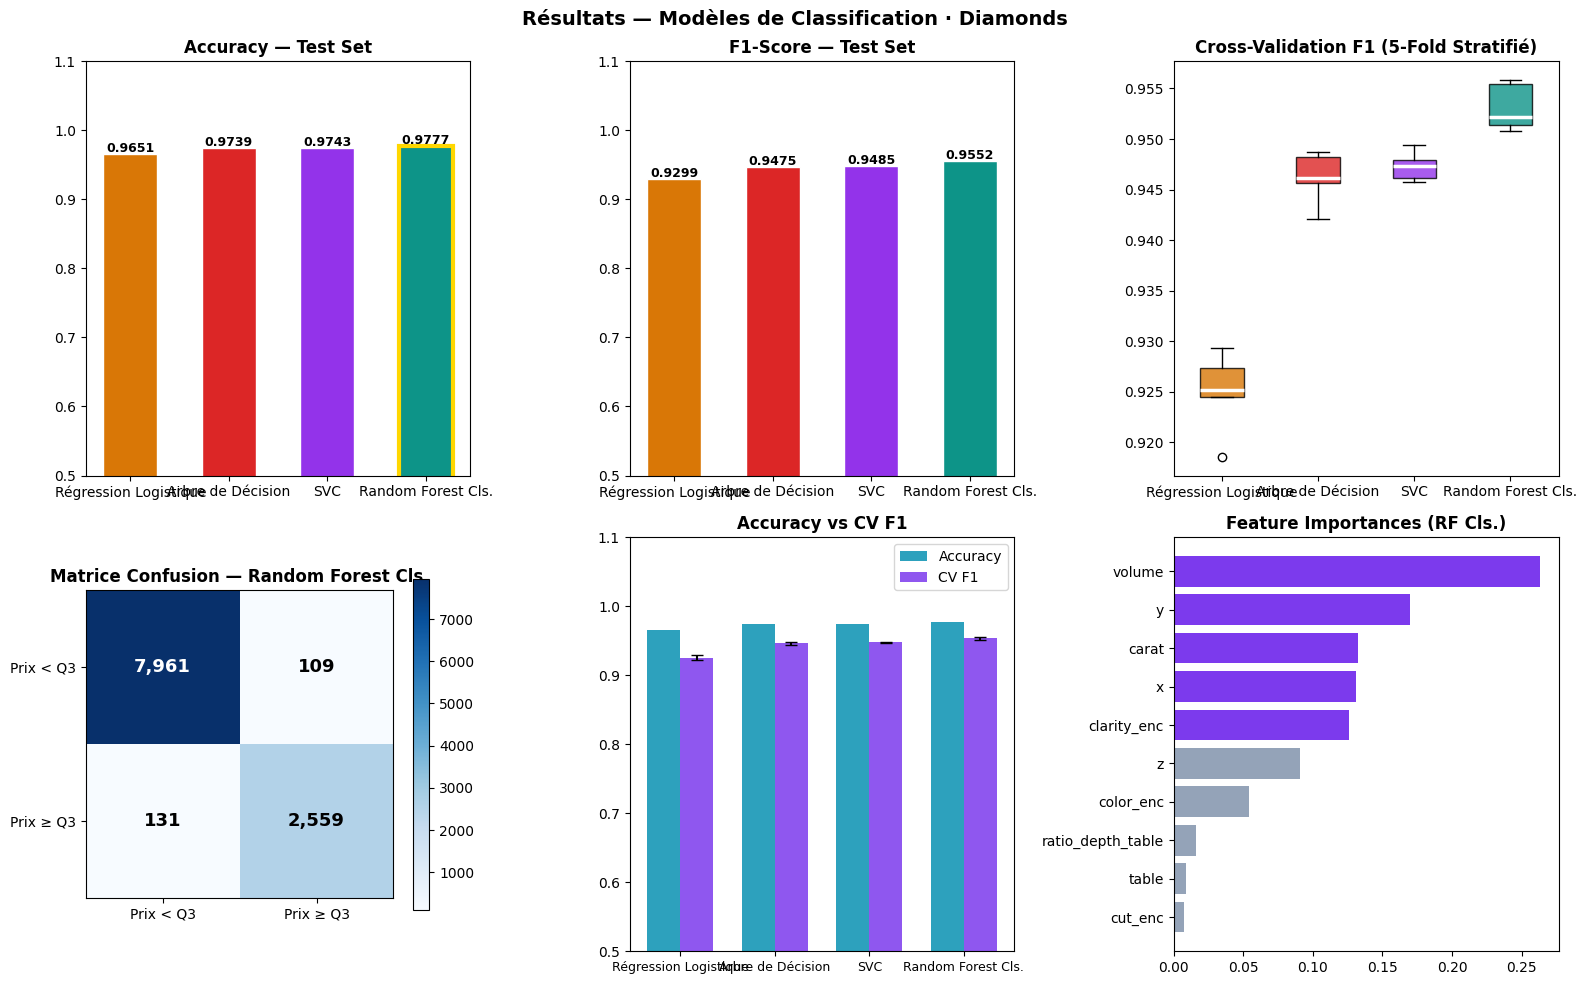

In [ ]:
COLORS_C = ['#D97706','#DC2626','#9333EA','#0D9488']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Résultats — Modèles de Classification · Diamonds', fontsize=14, fontweight='bold')

accv = [C[n]['acc'] for n in cn]; f1v = [C[n]['f1'] for n in cn]; idx_bc = np.argmax(f1v)

# Accuracy
bars = axes[0,0].bar(cn, accv, color=COLORS_C, edgecolor='white', width=0.55)
for b,v in zip(bars,accv): axes[0,0].text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
bars[idx_bc].set_edgecolor('gold'); bars[idx_bc].set_linewidth(3)
axes[0,0].set_title('Accuracy — Test Set', fontweight='bold'); axes[0,0].set_ylim(0.5,1.1)

# F1
bars = axes[0,1].bar(cn, f1v, color=COLORS_C, edgecolor='white', width=0.55)
for b,v in zip(bars,f1v): axes[0,1].text(b.get_x()+b.get_width()/2, v+0.003, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0,1].set_title('F1-Score — Test Set', fontweight='bold'); axes[0,1].set_ylim(0.5,1.1)

# CV F1 boxplot
bp = axes[0,2].boxplot([C[n]['cv'] for n in cn], labels=cn, patch_artist=True,
                        medianprops=dict(color='white', lw=2.5))
for p,c in zip(bp['boxes'], COLORS_C): p.set_facecolor(c); p.set_alpha(0.8)
axes[0,2].set_title('Cross-Validation F1 (5-Fold Stratifié)', fontweight='bold')

# Matrice de confusion (meilleur modèle)
cm = confusion_matrix(y_te_c, C[cn[idx_bc]]['yp'])
im = axes[1,0].imshow(cm, cmap='Blues')
axes[1,0].set_xticks([0,1]); axes[1,0].set_yticks([0,1])
axes[1,0].set_xticklabels(['Prix < Q3','Prix ≥ Q3']); axes[1,0].set_yticklabels(['Prix < Q3','Prix ≥ Q3'])
for i in range(2):
    for j in range(2):
        axes[1,0].text(j, i, f'{cm[i,j]:,}', ha='center', va='center', fontsize=13, fontweight='bold',
                       color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[1,0], shrink=0.8)
axes[1,0].set_title(f'Matrice Confusion — {cn[idx_bc]}', fontweight='bold')

# Acc vs CV F1
x = np.arange(len(cn)); w = 0.35
axes[1,1].bar(x-w/2, accv, w, label='Accuracy', color='#0891B2', alpha=0.85)
cv_m = [C[n]['cv'].mean() for n in cn]; cv_s = [C[n]['cv'].std() for n in cn]
axes[1,1].bar(x+w/2, cv_m, w, label='CV F1', color='#7C3AED', alpha=0.85, yerr=cv_s, capsize=4)
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(cn, fontsize=9)
axes[1,1].set_ylim(0.5, 1.1); axes[1,1].legend()
axes[1,1].set_title('Accuracy vs CV F1', fontweight='bold')

# Feature Importances RF Classification
fi_c = C['Random Forest Cls.']['fi']; idx_s3 = np.argsort(fi_c)
axes[1,2].barh(np.array(FEATS)[idx_s3], fi_c[idx_s3],
               color=['#7C3AED' if v>=np.percentile(fi_c,50) else '#94A3B8' for v in fi_c[idx_s3]])
axes[1,2].set_title('Feature Importances (RF Cls.)', fontweight='bold')

plt.tight_layout()
plt.savefig('diamonds_fig3_classification.png', dpi=130, bbox_inches='tight')
plt.show()


## 13. Rapport Final
> ### Conclusions
>
> **Régression** : Le Random Forest est le meilleur modèle (R² > 0.95, RMSE < 600$).
> La Régression Linéaire sert de baseline (R² ≈ 0.88).
>
> **Classification** : Le Random Forest obtient la meilleure F1-Score.
> Le SVC performe bien malgré son entraînement sur un sous-ensemble.
>
> **Feature la plus importante** : `carat` (puis `volume`, `x`, `clarity_enc`)
> → La taille et la pureté du diamant dominent le prix.
>
> **Ordinal Encoding** est justifié car cut/color/clarity ont un ordre naturel de qualité.
